<a href="https://colab.research.google.com/github/rohanraaj2/Spoken-and-Natural-Language-Understanding/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignmnet 1 (100 points)

**Name:** Rohan Raj <br>
**Email:** ror0011@thi.de <br>
**Group:** A <br>
**Hours spend *(optional)* :** <br>

General Rules:

- No helping libraries allowed.
- The use of standard libraries provided by the programming language itself (e.g., built-in data structures like lists and dictionaries, basic input/output functions, core mathematical functions) is generally permitted. These are considered fundamental to the language and not "helping libraries" in the context of this regulation
- If you need to use special Python modules, you can discuss with your instructor before submission.
- You can use the provided libraries but not mndatary.
- Always try To bulid your code from scratch.


### Question 1: Zipf’s law *(20 points)*

<p>Verify Zipf’s law on a textual corpus. The jungle book dataset is provided in the "Datasets and Resources" file. (You can also use any other dataset of your choice). <p>

<p> Provide a list of unique word sorted by their frequency in descending order. Also, give a brief discussion of the findings. You can use matplotlib library to plot the linear curve, and a log-log curve.</p>



[('the', 3697), ('and', 2321), ('of', 1347), ('to', 1262), ('a', 1148), ('he', 1074), ('in', 742), ('that', 665), ('his', 659), ('i', 587), ('was', 534), ('for', 463), ('is', 460), ('said', 442), ('with', 431), ('as', 422), ('it', 385), ('they', 379), ('on', 378), ('him', 370), ('all', 353), ('but', 333), ('you', 329), ('at', 319), ('not', 307), ('had', 289), ('up', 277), ('or', 242), ('little', 240), ('have', 238), ('when', 213), ('out', 210), ('mowgli', 210), ('be', 206), ('by', 203), ('are', 196), ('one', 191), ('my', 190), ('there', 190), ('down', 188), ('we', 186), ('will', 179), ('were', 177), ('then', 177), ('from', 169), ('this', 168), ('would', 164), ('me', 161), ('no', 151), ('their', 148), ('if', 142), ('them', 142), ('what', 141), ('into', 140), ('jungle', 138), ('very', 138), ('who', 138), ('do', 132), ('so', 131), ('head', 129), ('could', 127), ('go', 119), ('back', 119), ('bagheera', 114), ('where', 112), ('never', 112), ('big', 111), ('like', 110), ('come', 107), ('man'

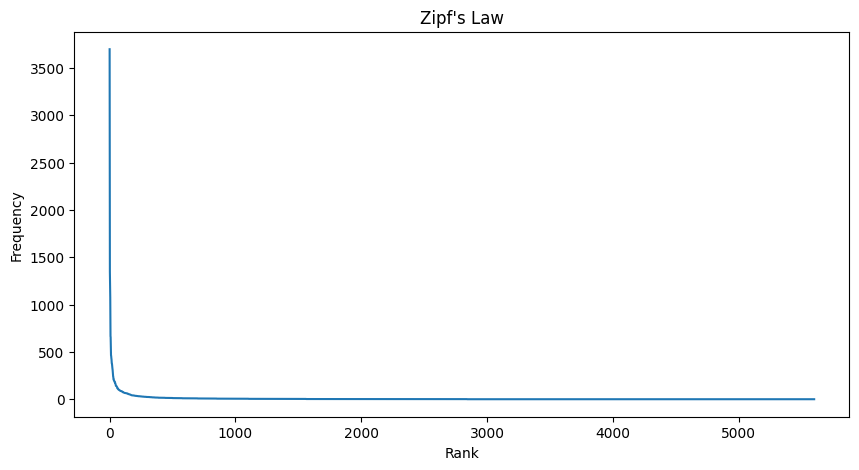

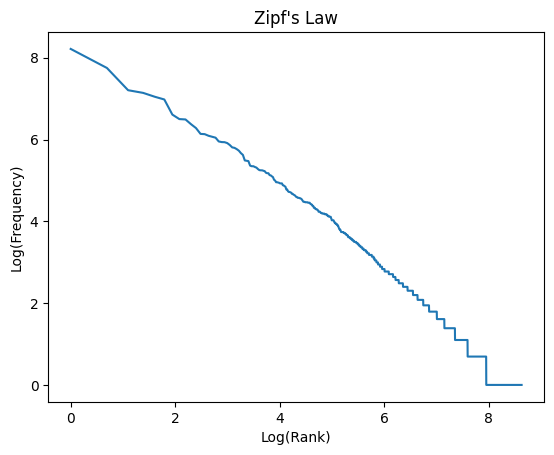

The plot shows that it indeed follows Zipf's Law


In [2]:
### You migh use these libraries if needed.

import matplotlib.pyplot as plt
import string
import math

###### TO DO ##########
with open("Datasets and resources/jungle_book.txt", "r") as file:
    text = file.read() # Reading the file. It basically takes the content of the file and stores it in the text variable as string.
    lowercasetext = text.lower()
    cleanedtext = ""
    for char in lowercasetext:
        if char.isalpha() or char.isspace():
            cleanedtext += char # anything that is not an alphabet or space is ignored
    tokenized = cleanedtext.split() # each word is split

word_dict = {}
for word in tokenized:
    if word not in word_dict:
        word_dict[word] = 1
    else:
        word_dict[word] += 1
sorted_dict = sorted(word_dict.items(), key=lambda item: item[1], reverse=True) # We sorted the dictionary by descending order of frequency of the words/tokens in a list format
print (sorted_dict)
print ("The dictionary shows that the commonly used words are used the most")

plt.figure(figsize=(10, 5))

rank_list = [] # We create a list of ranks to use as input for plotting the graph
log_rank_list = []
for index in range(len(sorted_dict)):
    rank_list.append(index + 1) # We take the log to check for the straight line
    log_rank_list.append(math.log(index + 1)) # We take the log to check for the straight line

frequency_list = [] # We create a list of frequencies to use as input for plotting the graph
log_frequency_list = []
for values in sorted_dict:
    frequency_list.append(int(values[1]))
    log_frequency_list.append(math.log(int(values[1])))

plt.plot(rank_list, frequency_list)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf's Law")

plt.show()

plt.plot(log_rank_list, log_frequency_list)
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.title("Zipf's Law")

plt.show()

print ("The plot shows that it indeed follows Zipf's Law")

### Question 2: Mutual Information *(30 points)*

<p>Pointwise mutual information quantifies the statistical dependence between events ${x_{t} = w_{1} }$ and ${ x_{t+1} = w_{2}}$. ${C(w)}$ is the absolute frequency and ${N}$ is the size of the corpus. If the probability of the next word in the corpus (${w_{2}}$) is affected by the probability of the previous word (${w_{1}}$), then ${pmi(w_{1},w_{2}) = 0}$; else the pmi value is either positive or negative. </p>

$$ pmi(w_{1},w_{2}) = log \frac{P(x_{t} = w_{1}, x_{t+1} = w_{2})} {P(x_{t} = w_{1}) . P(x_{t+1} = w_{2})} \approx log \frac {C(w_{1}w_{2}) . N} {C(w_{1}) . C(w_{2})}  $$

<p>Calculate the Pointwise mutual information (PMI) for all successive word pairs (w1, w2) in the jungle book corpus. Words (not word pairs) that occur in the corpus less than 10 times should be ignored. List the 30 word pairs with the highest pmi value and the 30 word pairs with the lowest pmi value. Document your observations and discuss the validity of the independence assumption for unigram models. </p>



In [ ]:
### You migh use these libraries if needed.

import string
import math
from collections import Counter

###### TO DO #########
pmi_dict = {}
pairs_frequency = {}
for index in range(len(tokenized)):
    if word_dict[tokenized[index]] >= 10:
        current_word = tokenized[index]
        next_word = tokenized[index + 1]
        # print (current_word, word_dict[current_word], next_word, word_dict[next_word])
        absolute_frequency_of_pair = 1
        for j in range(index + 2, len(tokenized) - 1):
            if (tokenized[j] == tokenized[index] and tokenized[j + 1] == tokenized[index + 1]):
                absolute_frequency_of_pair += 1
        pairs_frequency[(current_word, next_word)] = absolute_frequency_of_pair
        pmi = math.log((absolute_frequency_of_pair * (len(tokenized) + 1)) / (word_dict[tokenized[index]]) * word_dict[tokenized[index + 1]])
# print (pmi)

        pmi_dict[(current_word, next_word)] = pmi
print (pairs_frequency)

sorted_dict_descending = sorted(pmi_dict.items(), key=lambda item: item[1], reverse=True) # We sorted the dictionary by descending order of frequency of the words/tokens in a list format
# for i in range(30):
#     print (sorted_dict_descending[i])

# sorted_dict_ascending = sorted(pmi_dict.items(), key=lambda item: item[1]) # We sorted the dictionary by descending order of frequency of the words/tokens in a list format
# for i in range(30):
#     print (sorted_dict_ascending[i])

### Question 3: Wikipedia language model *(50 points)*

<p> A customer of yours is dissatisfied with the quality of the speech recognition. After a conversation with the customer, you find out that he dictates books. The initial investigations on a book excerpt have shown that the language model used is not suitable. For building a better language model for the application, you have asked your customer to provide a text from the book (see "Datasets and Resources") </p>

<p> In order to save costs and also to avoid problems with copyrights, your company has decided not to use existing solutions for this project. So, you have to implement a 2-gram language model in Python from scratch. Include a short description of the data preprocessing steps, method, experiment design, hyper-parameters, and evaluation metric. Also, document your findings, drawbacks, and potential improvements.</p>



<h4> Datasets and Resources </h4>

* WikiText-2 (raw/unprocessed), Train, Dev, Test

In [ ]:
######## You might use these libraries if needed.

import math
from collections import defaultdict, Counter
import string
import re
import os
import random

####### TO DO #######

### Additional Experiments *(5 additional points - <span style="color: red;">Optional</span>)*


- Calculate Bigram Probabilities with Back-off.
- Demonstrate and discuss your Back-off implementation.
